# Meesho Data Analysis

In [16]:
#Importing Important Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [17]:
#Loading the Dataset
orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category = pd.read_csv("product_category_name_translation.csv")

In [18]:
#understanding the Dataset
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [19]:
orders.shape

(99441, 8)

In [20]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [21]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Create Delivery Time Feature

In [22]:
orders['delivery_time'] = (
    orders['order_delivered_customer_date'] - 
    orders['order_purchase_timestamp']
).dt.days

# Merge Datasets (Industry Data Modeling)

In [23]:
df = orders.merge(customers, on="customer_id")
df = df.merge(items, on="order_id")
df = df.merge(products, on="product_id")
df = df.merge(payments, on="order_id")
df = df.merge(sellers, on="seller_id")

# Translate Product Categories

In [24]:
df = df.merge(category,
              left_on="product_category_name",
              right_on="product_category_name",
              how="left")

#  Feature Engineering

In [25]:
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month

# Total Revenue

In [26]:
total_revenue = df['price'].sum()

print("Total Revenue:", round(total_revenue,2))

Total Revenue: 14209115.34


# Top Product Categories

In [27]:
category_sales = df.groupby(
    "product_category_name_english"
)["price"].sum().sort_values(ascending=False)

category_sales.head(10)

product_category_name_english
health_beauty            1297355.80
watches_gifts            1253143.30
bed_bath_table           1092551.02
sports_leisure           1023996.34
computers_accessories     942277.57
furniture_decor           765093.89
housewares                666587.00
cool_stuff                662309.49
auto                      616752.51
garden_tools              518217.54
Name: price, dtype: float64

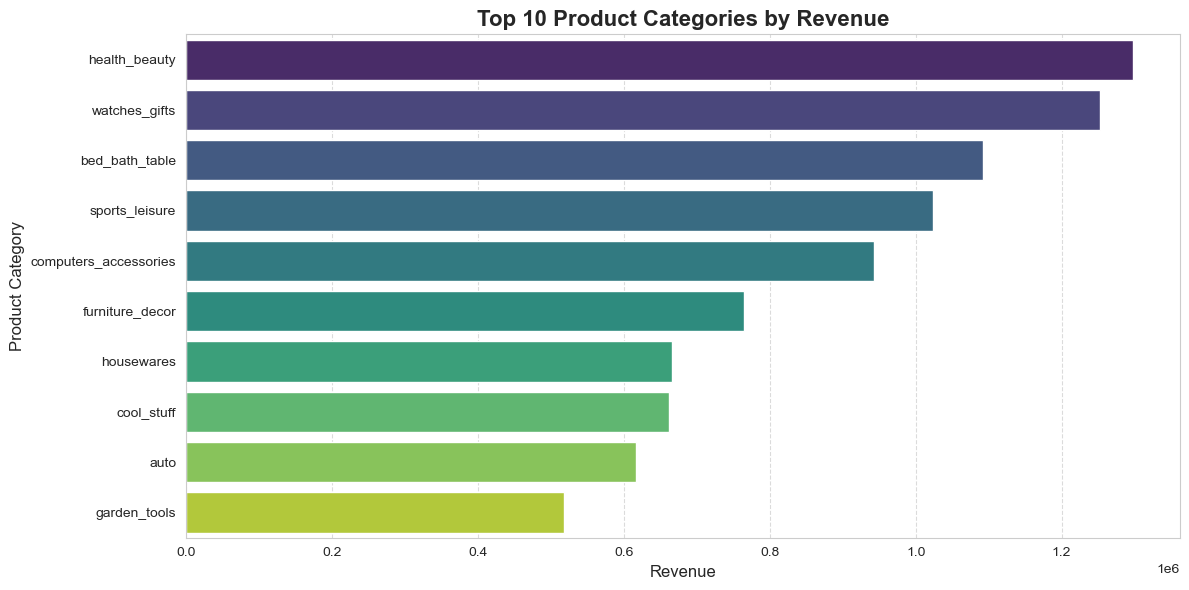

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

top_categories = category_sales.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
    palette="viridis"
)

plt.title("Top 10 Product Categories by Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Revenue", fontsize=12)
plt.ylabel("Product Category", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Monthly Sales Trend

In [29]:
monthly_sales = df.groupby("month")["price"].sum()

monthly_sales

month
1     1115789.40
2     1140853.65
3     1422387.10
4     1421256.72
5     1577491.09
6     1362252.51
7     1458919.30
8     1486067.07
9      662553.78
10     744749.83
11    1046127.84
12     770667.05
Name: price, dtype: float64

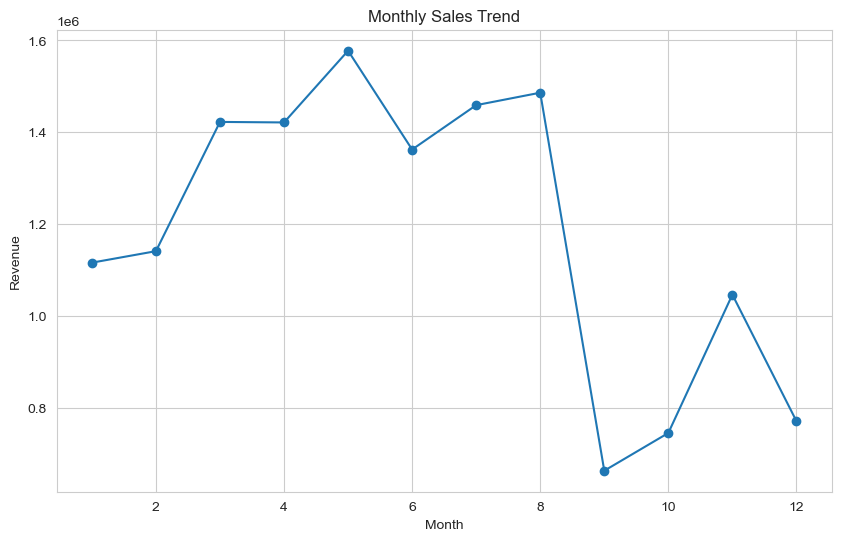

In [30]:
plt.plot(monthly_sales, marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

# Top Cities by Orders

In [31]:
city_orders = df.groupby("customer_city")["order_id"].count().sort_values(ascending=False)

city_orders.head(10)

customer_city
sao paulo                18590
rio de janeiro            8202
belo horizonte            3247
brasilia                  2457
curitiba                  1809
campinas                  1735
porto alegre              1654
salvador                  1527
guarulhos                 1401
sao bernardo do campo     1112
Name: order_id, dtype: int64

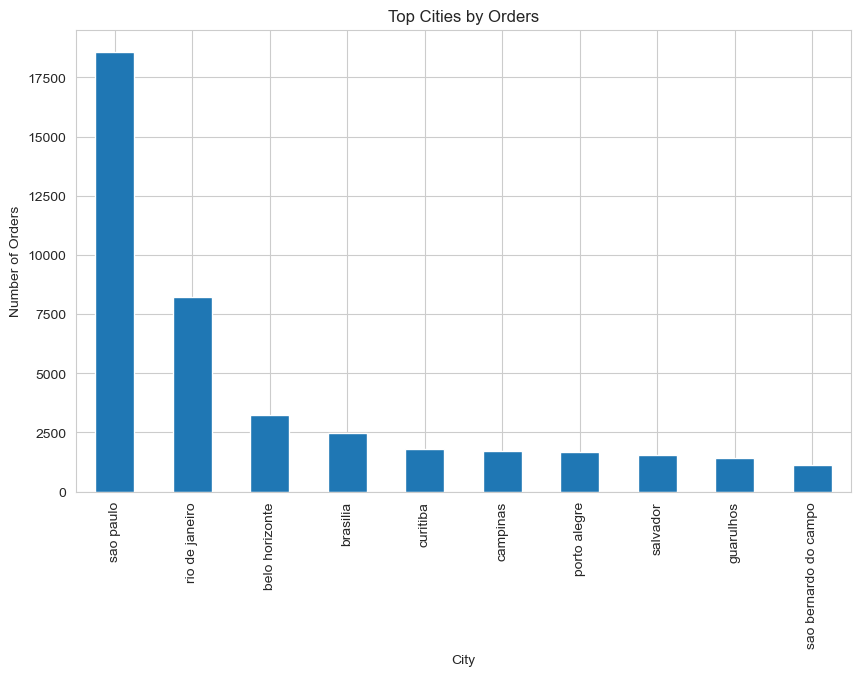

In [32]:
city_orders.head(10).plot(kind="bar")

plt.title("Top Cities by Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")

plt.show()

# Payment Method Distribution

In [33]:
payment_counts = df['payment_type'].value_counts()

payment_counts

payment_type
credit_card    86769
boleto         22867
voucher         6274
debit_card      1691
Name: count, dtype: int64

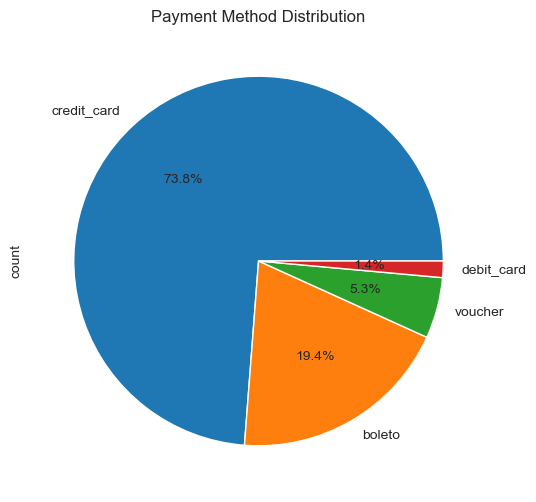

In [37]:
payment_counts.plot(kind="pie", autopct="%1.1f%%")

plt.title("Payment Method Distribution")

plt.show()

#  Seller Performance

In [38]:
seller_sales = df.groupby("seller_id")["price"].sum().sort_values(ascending=False)

seller_sales.head(10)

seller_id
53243585a1d6dc2643021fd1853d8905    244627.55
4869f7a5dfa277a7dca6462dcf3b52b2    237867.23
4a3ca9315b744ce9f8e9374361493884    213299.57
fa1c13f2614d7b5c4749cbc52fecda94    203984.22
7c67e1448b00f6e969d365cea6b010ab    198194.33
7e93a43ef30c4f03f38b393420bc753a    182878.17
da8622b14eb17ae2831f4ac5b9dab84a    169297.77
7a67c85e85bb2ce8582c35f2203ad736    149939.84
1025f0e2d44d7041d6cf58b6550e0bfa    142130.94
955fee9216a65b617aa5c0531780ce60    137335.00
Name: price, dtype: float64

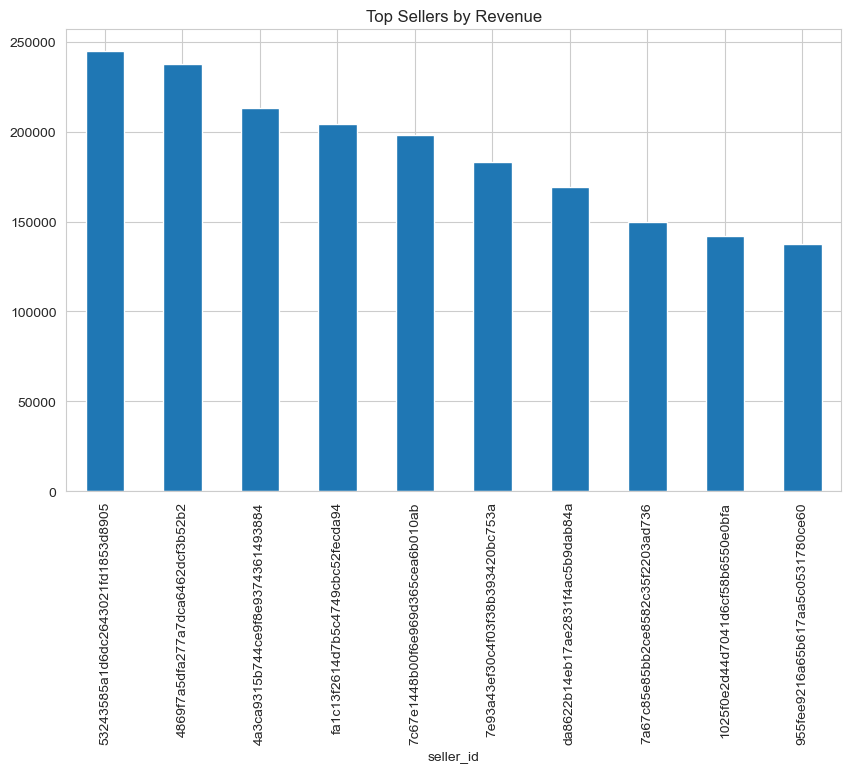

In [39]:
seller_sales.head(10).plot(kind="bar")

plt.title("Top Sellers by Revenue")

plt.show()

#  Delivery Time Analysis

In [40]:
df['delivery_time'].mean()

np.float64(12.018142462228559)

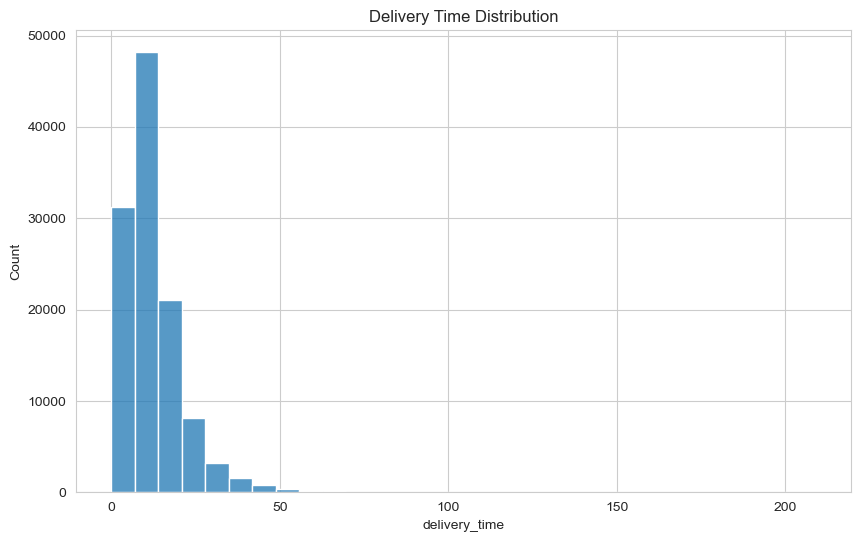

In [41]:
sns.histplot(df['delivery_time'], bins=30)

plt.title("Delivery Time Distribution")

plt.show()

# Customer Review Analysis

In [42]:
df = df.merge(reviews[['order_id','review_score']], on="order_id", how="left")

In [43]:
ratings = df.groupby("product_category_name_english")['review_score'].mean().sort_values(ascending=False)

ratings.head(10)

product_category_name_english
cds_dvds_musicals                        4.642857
fashion_childrens_clothes                4.500000
books_general_interest                   4.438503
books_imported                           4.419355
flowers                                  4.419355
costruction_tools_tools                  4.415842
books_technical                          4.375465
food_drink                               4.324138
small_appliances_home_oven_and_coffee    4.320513
luggage_accessories                      4.295945
Name: review_score, dtype: float64

# Correlation Analysis

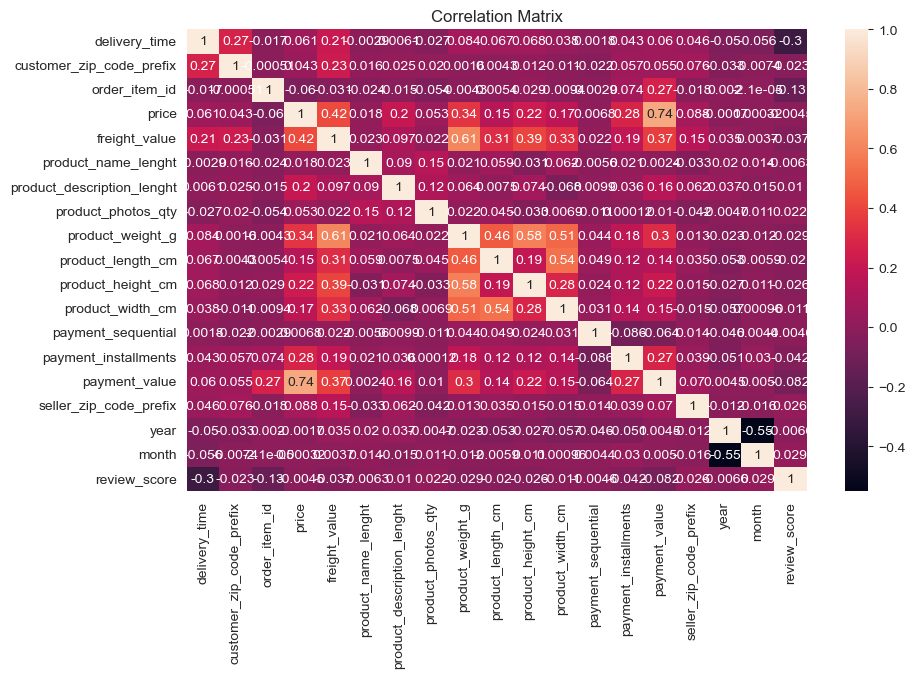

In [44]:
numeric = df.select_dtypes(include=np.number)

sns.heatmap(numeric.corr(), annot=True)

plt.title("Correlation Matrix")

plt.show()